# 03 - Modelling

Steps:
- Trivial baseline (predict *pass* for everything)
- Logistic regression
- Random forest
- Histogram gradient boosting
- Model comparison
- Decision threshold

Everything is scored with cross-validation on the training fold.

Primary metric is **PR-AUC** (average precision): it summarises the precision/recall
trade-off across all thresholds and focuses on the rare failure class, so unlike
accuracy it can't be fooled by a model that just predicts *pass*.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (make_scorer, precision_score, recall_score,
                             ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.utils.class_weight import compute_sample_weight

from src.preprocessing import split_secom, build_preprocessor
from src.evaluate import dummy_baseline_accuracy, evaluate, summarise_cv, threshold_sweep

In [2]:
X_train, X_test, y_train, y_test = split_secom(test_size=0.20, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'train: {len(X_train)} rows, {y_train.sum()} fails ({y_train.mean():.3f})')

train: 1253 rows, 83 fails (0.066)


In [3]:
def run(clf, sample_weight=None):
    # helper function: out-of-fold predictions for a classifier, 
    # with the preprocessor inside the pipeline so it's re-fit within each fold
    pipe = Pipeline([('pre', build_preprocessor()), ('clf', clf)])
    fit_params = {}
    if sample_weight is not None:
        # route sample weights to the classifier step inside the pipeline
        fit_params['clf__sample_weight'] = sample_weight
    pred  = cross_val_predict(pipe, X_train, y_train, cv=cv, params=fit_params)
    score = cross_val_predict(pipe, X_train, y_train, cv=cv,
                              method='predict_proba', params=fit_params)[:, 1]
    return evaluate(y_train, pred, score), score

results = {}  
scores  = {}  

## 1. Trivial baseline

Dummy classifier that predicts *pass* for everything, catches zero defects.

In [4]:
print(f'all-pass accuracy: {dummy_baseline_accuracy(y_train):.4f}')
results['all-pass'], scores['all-pass'] = run(DummyClassifier(strategy='most_frequent'))
pd.Series(results['all-pass']).to_frame('all-pass').T.round(3)

all-pass accuracy: 0.9338


,accuracy,recall,precision,mcc,tp,fn,fp,tn,pr_auc,roc_auc
all-pass,0.934,0.0,0.0,0.0,0.0,83.0,0.0,1170.0,0.066,0.5


The dummy classifier predicts pass for everything, yet scores 93.4% accuracy (while catching 0 of the 83 failures). So accuracy is not a reliable metric on imbalanced datasets. The other metrics (recall, precision, MCC) are all 0 which correctly shows that the model catches nothing, so those metrics will be more reliable to assess the other classifiers.

## 2. Logistic regression

Linear baseline. `class_weight='balanced'` makes class weights proportional to class frequencies so it upweights the rare failures.

In [5]:
results['logreg'], scores['logreg'] = run(
    LogisticRegression(max_iter=2000, class_weight='balanced')
)
pd.Series(results['logreg']).to_frame('logistic regression').T.round(3)

,accuracy,recall,precision,mcc,tp,fn,fp,tn,pr_auc,roc_auc
logistic regression,0.849,0.265,0.147,0.119,22.0,61.0,128.0,1042.0,0.119,0.613


With PR-AUC and MCC at 0.119, the model is clearly learning something from the data, unlike the dummy classifier (it catches 22 of the 83 failures). Recall and precision here are measured at the default 0.5 threshold, which section 6 revisits, but PR-AUC summarizes performance across all thresholds, so it gives a more complete picture of the model than the other metrics.

## 3. Random forest

Captures non-linear structure and interactions the linear model can't.

In [6]:
results['random forest'], scores['random forest'] = run(
    RandomForestClassifier(n_estimators=500, class_weight='balanced',
                           min_samples_leaf=2, random_state=42, n_jobs=-1)
)
pd.Series(results['random forest']).to_frame('random forest').T.round(3)

,accuracy,recall,precision,mcc,tp,fn,fp,tn,pr_auc,roc_auc
random forest,0.933,0.0,0.0,-0.008,0.0,83.0,1.0,1169.0,0.168,0.709


At the default 0.5 threshold the random forest catches none of the 83 defects, the same as the dummy classifier. But its PR-AUC of 0.168 is higher than logistic regression's 0.119, which suggests the model ranks failures reasonably well even though the 0.5 cutoff does not show it. Section 6 checks whether a lower threshold results in usable metrics.

## 4. Histogram gradient boosting

A modern boosting model to check if a stronger model class extract more signal than the other classifiers.

Note: `HistGradientBoostingClassifier` has no `class_weight` parameter, so we calculate balanced sampled weights and pass that instead.

In [7]:
sw = compute_sample_weight('balanced', y_train)

results['hist gbm'], scores['hist gbm'] = run(
    HistGradientBoostingClassifier(random_state=42),
    sample_weight=sw,
)
pd.Series(results['hist gbm']).to_frame('hist gbm').T.round(3)

,accuracy,recall,precision,mcc,tp,fn,fp,tn,pr_auc,roc_auc
hist gbm,0.929,0.024,0.2,0.048,2.0,81.0,8.0,1162.0,0.157,0.713


Gradient boosting is a stronger model class than a random forest on most tabular problems, so if there were more signal to extract, it would show up in this result. However its PR-AUC of 0.157 lands basically level with the random forest's 0.168, slightly lower.  Two different model families reaching the same place points to the limit being the signal in the data rather than the choice of model. A more capable model did not find more, which indicates that the ceiling here is the dataset, not the method.



## 5. Model comparison

All models side by side.

In [8]:
comparison = pd.DataFrame(results).T[
    ['accuracy', 'pr_auc', 'roc_auc', 'recall', 'precision', 'mcc', 'tp', 'fn', 'fp']
]
comparison.round(3)

,accuracy,pr_auc,roc_auc,recall,precision,mcc,tp,fn,fp
all-pass,0.934,0.066,0.500,0.000,0.000,0.000,0.0,83.0,0.0
logreg,0.849,0.119,0.613,0.265,0.147,0.119,22.0,61.0,128.0
random forest,0.933,0.168,0.709,0.000,0.000,-0.008,0.0,83.0,1.0
hist gbm,0.929,0.157,0.713,0.024,0.200,0.048,2.0,81.0,8.0


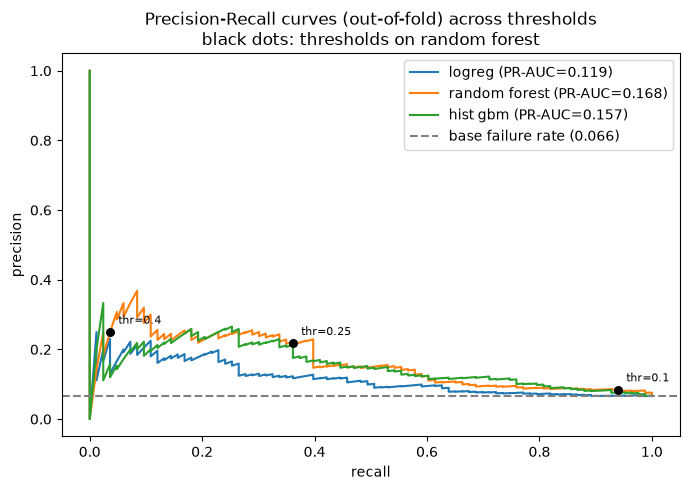

In [9]:
# PR curves: the honest diagnostic plot for imbalanced problems
fig, ax = plt.subplots(figsize=(7, 5))

curve_data = {}  # stash each model's curve so we can annotate one below
for name, s in scores.items():
    if name == 'all-pass':          # skip the dummy classifier
        continue
    prec, rec, thr = precision_recall_curve(y_train, s)
    curve_data[name] = (prec, rec, thr)
    ap = results[name]['pr_auc']
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})')

# annotate a few thresholds on the best model's curve, to show that
# moving along a curve means moving the decision threshold
best_name = max(curve_data, key=lambda n: results[n]['pr_auc'])
prec, rec, thr = curve_data[best_name]
for t in [0.10, 0.25, 0.40]:
    i = int(np.argmin(np.abs(thr - t)))          # nearest curve point to threshold t
    ax.scatter(rec[i], prec[i], color='black', zorder=5, s=30)
    ax.annotate(f'thr={t}', (rec[i], prec[i]),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

ax.axhline(y_train.mean(), ls='--', color='grey',
           label=f'base failure rate ({y_train.mean():.3f})')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title(f'Precision-Recall curves (out-of-fold) across thresholds\nblack dots: thresholds on {best_name}')
ax.legend()
plt.tight_layout(); plt.show()

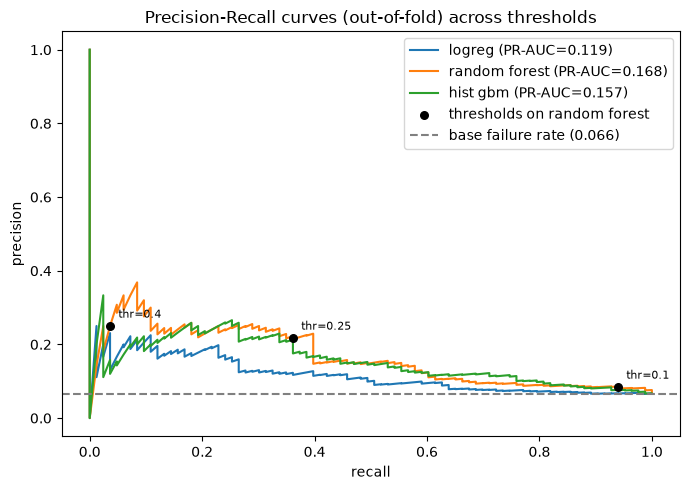

In [10]:
# PR curves: the honest diagnostic plot for imbalanced problems
fig, ax = plt.subplots(figsize=(7, 5))

curve_data = {}  # stash each model's curve so we can annotate one below
for name, s in scores.items():
    if name == 'all-pass':          # skip the dummy classifier
        continue
    prec, rec, thr = precision_recall_curve(y_train, s)
    curve_data[name] = (prec, rec, thr)
    ap = results[name]['pr_auc']
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})')

# annotate a few thresholds on the best model's curve, to show that
# moving along a curve means moving the decision threshold
best_name = max(curve_data, key=lambda n: results[n]['pr_auc'])
prec, rec, thr = curve_data[best_name]
for j, t in enumerate([0.10, 0.25, 0.40]):
    i = int(np.argmin(np.abs(thr - t)))          # nearest curve point to threshold t
    ax.scatter(rec[i], prec[i], color='black', zorder=5, s=30,
               label=f'thresholds on {best_name}' if j == 0 else None)
    ax.annotate(f'thr={t}', (rec[i], prec[i]),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

ax.axhline(y_train.mean(), ls='--', color='grey',
           label=f'base failure rate ({y_train.mean():.3f})')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-Recall curves (out-of-fold) across thresholds')
ax.legend()
plt.tight_layout(); plt.show()

The plot shows the recall and precision performance of the classifiers across different decision thresholds. RF and HistGBM curves sit highest and close together with the logreg curve below them, which matches the PR-AUC order. All three classifiers sit above the base failure rate but not too high, which shows they learn something real but the signal in the data is limited. For the model with the highest PR-AUC, RF, a few threshold points are marked with black dots to show where different cutoffs fall along the curve (section 6 identifies which threshold actually works best).

## 6. Decision threshold

Pick the best model on PR-AUC and look at its behaviour across thresholds.

In [11]:
best_name = max((n for n in results if n != 'all-pass'),
                key=lambda n: results[n]['pr_auc'])
print(f'best model on PR-AUC: {best_name}')
best_score = scores[best_name]

sweep = threshold_sweep(y_train, best_score)
sweep.round(3)

best model on PR-AUC: random forest


,recall,precision,mcc,flagged,missed_failures
threshold,,,,,
0.05,1.000,0.068,0.038,1228,0
0.10,0.940,0.084,0.122,924,5
0.15,0.639,0.107,0.132,497,30
0.20,0.470,0.150,0.172,260,44
0.25,0.361,0.219,0.215,137,53
0.30,0.181,0.246,0.163,61,68
0.35,0.096,0.296,0.137,27,75
0.40,0.024,0.182,0.044,11,81
0.45,0.000,0.000,-0.011,2,83


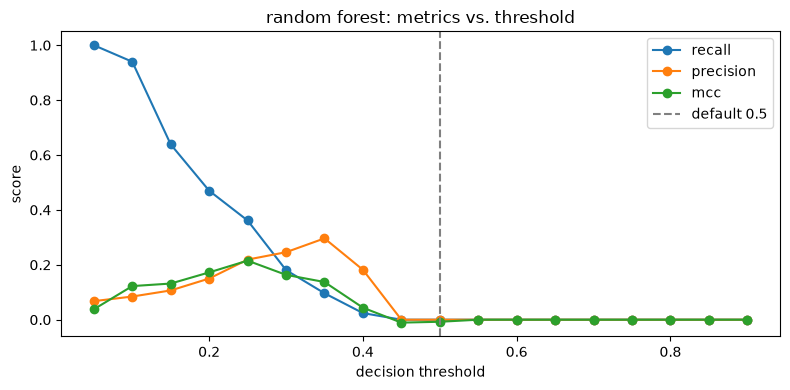

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
for m in ['recall', 'precision', 'mcc']:
    ax.plot(sweep.index, sweep[m], marker='o', label=m)
ax.axvline(0.5, ls='--', color='grey', label='default 0.5')
ax.set_xlabel('decision threshold'); ax.set_ylabel('score')
ax.set_title(f'{best_name}: metrics vs. threshold')
ax.legend()
plt.tight_layout(); plt.show()

We evaluate on MCC because it's a single number that summarizes the entire confusion matrix. 

Everything from 0.45 up is flat zero, so the default 0.5 threshold sits where the model catches nothing. We see that MCC peaks at 0.25, so that's the balance point.

MCC-optimal threshold on the sweep: 0.25


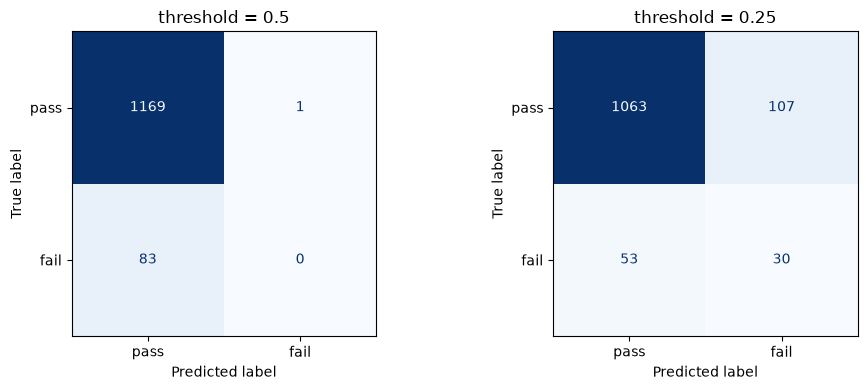

In [12]:
# confusion matrices: default 0.5 vs. an MCC-favourable threshold from the sweep
best_t = sweep['mcc'].idxmax()
print(f'MCC-optimal threshold on the sweep: {best_t}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, [0.5, best_t]):
    pred_t = (best_score >= t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_train, pred_t, display_labels=['pass', 'fail'],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'threshold = {t}')
plt.tight_layout(); plt.show()

At 0.25 threshold, the model flags 137 out of 1253 units and catches 30 of the defects, meaning that inspecting ~11% of production to catch ~36% of defects (3.3× lift over picking random units to inspect).

Findings:
- Accuracy is not a reliable metric for imbalanced datasets.
- HistGBM landed at PR-AUC 0.157 vs the random forest's 0.168, so a stronger model is not equal to better performance, the data decides the performance ceiling. 
- At the default 0.5 threshold the best model catches nothing; at 0.25 (MCC-optimal) it catches 36% of defects while inspecting 11% of units, a 3.3× lift.

**Next:** feature importance with stability checks across resamples.


## 7. Final test-set evaluation

Everything above was cross-validation on the training fold, and the test set has been untouched until now. The random forest is fit on the full training set and evaluated on the test set at the 0.25 threshold from the sweep. Because the threshold wasn't chosen using the test set, this is a fair estimate of performance on unseen data.

In [14]:
# chosen model, fit on the full training set
final_model = Pipeline([
    ('pre', build_preprocessor()),
    ('clf', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                   min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
final_model.fit(X_train, y_train)

# threshold chosen from the training-fold sweep, not from the test set
THRESHOLD = 0.25
test_score = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_score >= THRESHOLD).astype(int)

test_res = evaluate(y_test, test_pred, test_score)
print(f"test set at threshold {THRESHOLD}:")
print(f"  PR-AUC:    {test_res['pr_auc']:.3f}")
print(f"  recall:    {test_res['recall']:.3f}  (caught {test_res['tp']} of {test_res['tp']+test_res['fn']} failures)")
print(f"  precision: {test_res['precision']:.3f}")
print(f"  MCC:       {test_res['mcc']:.3f}")
print(f"  flagged {test_res['tp']+test_res['fp']} of {len(y_test)} units")

test set at threshold 0.25:
  PR-AUC:    0.252
  recall:    0.476  (caught 10 of 21 failures)
  precision: 0.333
  MCC:       0.347
  flagged 30 of 314 units


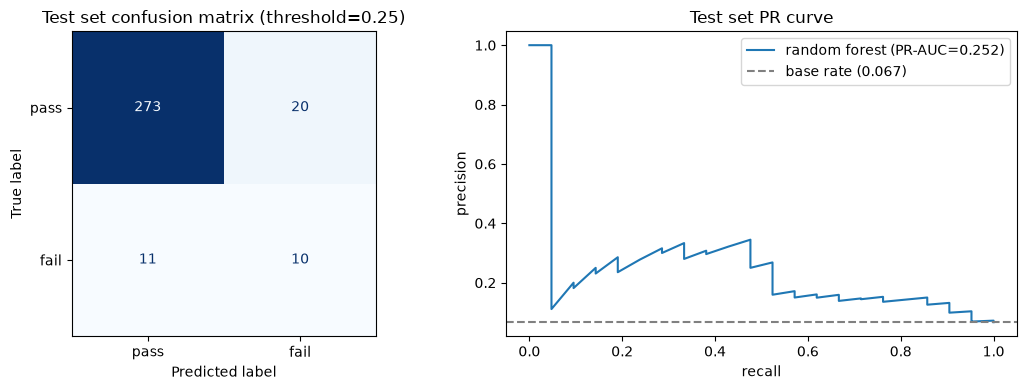

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# confusion matrix on the test set
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=['pass', 'fail'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Test set confusion matrix (threshold={THRESHOLD})')

# PR curve on the test set
prec, rec, _ = precision_recall_curve(y_test, test_score)
axes[1].plot(rec, prec, label=f"random forest (PR-AUC={test_res['pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), ls='--', color='grey',
                label=f'base rate ({y_test.mean():.3f})')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('Test set PR curve')
axes[1].legend()

plt.tight_layout(); plt.show()

Test PR-AUC is 0.252, slightly above the cross-validated 0.168, so the model held
up on data it hadn't seen. At the 0.25 threshold it caught 10 of 21 failures and
flagged 30 of 314 units, so inspecting about 10% of production catches roughly half
the defects. The test set only has 21 failures though, so there's real uncertainty
around these numbers.